# 02 · Arranque del bloque de diagnóstico

Este notebook es para Jonathan, aunque a cualquiera le sirve para entender la diferencia entre detectar y diagnosticar. Conviene haber pasado antes por `01_primeros_pasos`.

**Detectar** es responder sí o no: ¿hay fallo? Es lo que hace el PCA del notebook anterior, con datos solo de operación normal.

**Diagnosticar** es responder cuál: ¿qué fallo de los veinte es? Eso ya es clasificación supervisada, y necesita ejemplos etiquetados de cada tipo de fallo. Aquí montamos ese conjunto etiquetado con el paquete, entrenamos dos clasificadores clásicos como línea base, y vemos qué sale. El clustering difuso de la escuela del director —FCM, KFCM y la limpieza de valores atípicos— viene después y se compara contra esta línea base.

In [1]:
import os
from pathlib import Path
if not Path("data").exists() and Path("../data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tfmfdd import data, plots
from tfmfdd.preprocessing import Scaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

plots.use_style()

## 1. Montar el conjunto etiquetado → `data.py`

En el TEP clásico, los ficheros de **entrenamiento** de cada fallo (`d01.dat` a `d21.dat`) tienen el fallo activo desde la primera muestra: las 480 muestras son de ese fallo. El de operación normal, `d00.dat`, aporta la clase 0. Con eso el conjunto de entrenamiento es directo.

Los ficheros de **prueba** son distintos: 160 muestras normales y luego 800 con fallo. Para evaluar el diagnóstico se usan solo las 800 posteriores al inicio, que están etiquetadas por el fichero del que vienen. `data.FAULT_ONSET_TEST` guarda ese 160.

Recorremos los 22 ficheros y apilamos. La columna `faultNumber` que devuelve `load_classic` es directamente la etiqueta.

In [2]:
onset = data.FAULT_ONSET_TEST   # 160

X_tr, y_tr, X_te, y_te = [], [], [], []
for fault in range(22):
    tr = data.load_classic(fault, "train")
    te = data.load_classic(fault, "test")
    if fault > 0:
        te = te.iloc[onset:]        # solo las muestras con el fallo ya activo
    X_tr.append(data.values(tr)); y_tr.append(tr["faultNumber"].to_numpy())
    X_te.append(data.values(te)); y_te.append(te["faultNumber"].to_numpy())

X_tr, y_tr = np.vstack(X_tr), np.concatenate(y_tr)
X_te, y_te = np.vstack(X_te), np.concatenate(y_te)

print(f"Entrenamiento: {X_tr.shape}  ({len(np.unique(y_tr))} clases)")
print(f"Prueba       : {X_te.shape}")

Entrenamiento: (10580, 52)  (22 clases)
Prueba       : (17760, 52)


## 2. Estandarizar → `preprocessing.py`

`Scaler` se ajusta **solo con entrenamiento** y después se aplica a prueba. Si se ajustara con todo, el modelo vería información de los datos de prueba antes de evaluarse sobre ellos: eso es fuga de datos y produce cifras mejores de lo que son. Es el mismo `Scaler` que usa el PCA de Pablo, así que el preprocesado es idéntico en los dos bloques.

In [3]:
escalador = Scaler().fit(X_tr)
Z_tr = escalador.transform(X_tr)
Z_te = escalador.transform(X_te)
print("Media de Z_tr por variable ≈ 0:", np.abs(Z_tr.mean(axis=0)).max().round(6))
print("Media de Z_te por variable    :", np.abs(Z_te.mean(axis=0)).max().round(3), "(no es cero, y está bien que no lo sea)")

Media de Z_tr por variable ≈ 0: 0.0
Media de Z_te por variable    : 0.496 (no es cero, y está bien que no lo sea)


## 3. Dos clasificadores como línea base

kNN y Random Forest tal cual salen de scikit-learn, sin ajustar hiperparámetros. Son el suelo contra el que tiene que medirse cualquier método más elaborado: si el clustering difuso con toda su parafernalia no mejora a un Random Forest de serie, hay que decirlo.

Fíjate en que aquí la métrica de referencia ya no es FAR ni FDR, porque no es un problema de detección: es **F1 por clase** y **macro-F1**, que promedia el F1 de las 22 clases dando el mismo peso a cada una. Eso importa porque las clases difíciles no pueden esconderse detrás de las fáciles.

In [4]:
modelos = {
    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}
predicciones = {}
for nombre, m in modelos.items():
    m.fit(Z_tr, y_tr)
    predicciones[nombre] = m.predict(Z_te)
    print(f"{nombre:14s}  macro-F1 = {f1_score(y_te, predicciones[nombre], average='macro'):.3f}")

kNN (k=5)       macro-F1 = 0.392


Random Forest   macro-F1 = 0.634


## 4. Dónde falla cada uno

El macro-F1 resume, pero lo que informa es el **F1 por clase**. Aquí, para el Random Forest. Mira las clases 3, 9 y 15: son las mismas que el PCA no detectaba en el notebook anterior. No es casualidad, es la naturaleza de esos fallos.

,precision,recall,f1-score
fallo 3,0.170,0.201,0.185
fallo 9,0.161,0.188,0.173
fallo 15,0.140,0.175,0.155
fallo 1,0.995,0.990,0.992
fallo 6,1.000,0.998,0.999


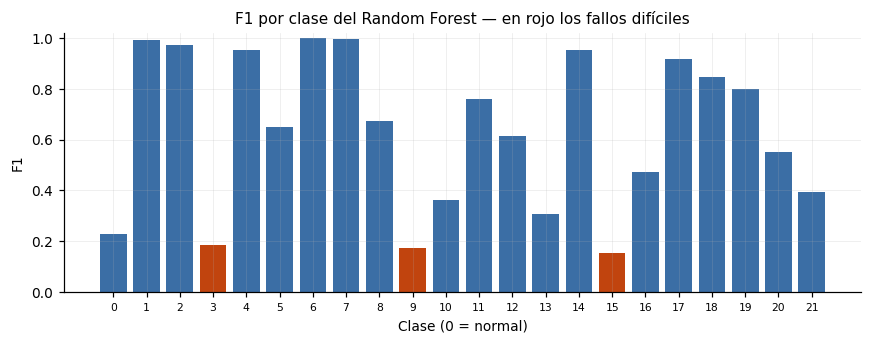

In [5]:
y_pred = predicciones["Random Forest"]
informe = pd.DataFrame(classification_report(y_te, y_pred, output_dict=True, zero_division=0)).T
informe = informe.iloc[:22][["precision", "recall", "f1-score"]].round(3)
informe.index = [f"fallo {i}" if i else "normal" for i in range(22)]

fig, ax = plt.subplots(figsize=(8, 3.2))
colores = [plots.COLORS["fault"] if i in (3, 9, 15) else plots.COLORS["normal"] for i in range(22)]
ax.bar(range(22), informe["f1-score"], color=colores)
ax.set_xticks(range(22)); ax.set_xticklabels(range(22), fontsize=7)
ax.set_xlabel("Clase (0 = normal)"); ax.set_ylabel("F1"); ax.set_ylim(0, 1.02)
ax.set_title("F1 por clase del Random Forest — en rojo los fallos difíciles")
plt.tight_layout()

informe.loc[["fallo 3", "fallo 9", "fallo 15", "fallo 1", "fallo 6"]]

## 5. La matriz de confusión

Dice **con qué se confunde** cada fallo, que es información que el F1 no da. Un diagnóstico que confunde el fallo 3 con el 9 es distinto de uno que lo confunde con el normal: en el primer caso al menos sabe que hay algo raro con la temperatura de alimentación.

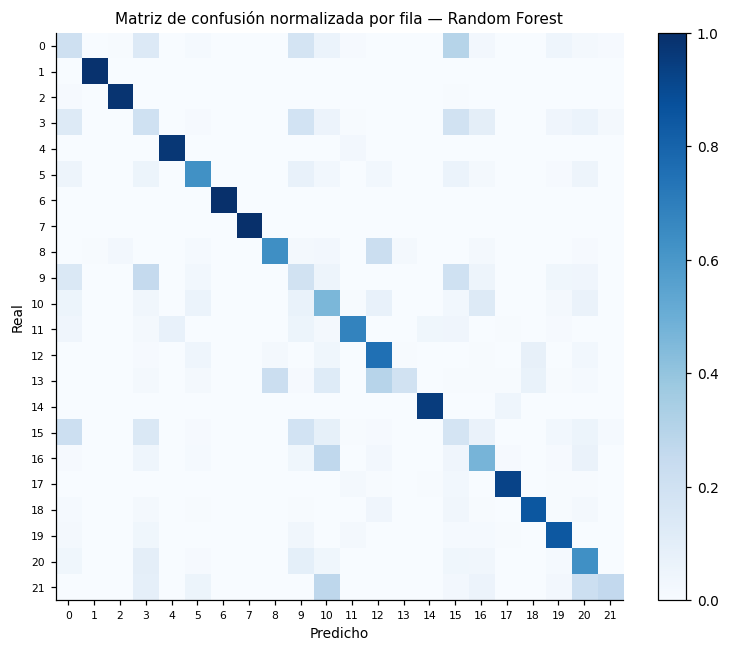

In [6]:
cm = confusion_matrix(y_te, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(22)); ax.set_yticks(range(22))
ax.set_xticklabels(range(22), fontsize=7); ax.set_yticklabels(range(22), fontsize=7)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión normalizada por fila — Random Forest")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## 6. Guardar en el formato común

Para que `metrics.aggregate` y las tablas de la memoria funcionen igual para los tres bloques, cada método guarda **una fila por simulación** con sus métricas. En el TEP clásico solo hay una simulación por fallo; en Rieth habrá cientos y aquí es donde salen los intervalos de confianza.

Este es el esquema que acordamos verificar entre los tres en la semana 5.

In [7]:
filas = []
for nombre, y_p in predicciones.items():
    for fault in range(22):
        m = y_te == fault
        filas.append({
            "method": nombre, "faultNumber": fault, "simulationRun": 1,
            "f1": f1_score(y_te[m], y_p[m], average="macro", labels=[fault], zero_division=0),
            "n": int(m.sum()),
        })
resultados = pd.DataFrame(filas)
resultados.to_csv("results/summary/B1_clasificadores_clasico.csv", index=False) if Path("results/summary").exists() else None
resultados.pivot(index="faultNumber", columns="method", values="f1").round(3).head(10)

method,Random Forest,kNN (k=5)
faultNumber,,
0,0.341,0.469
1,0.995,0.991
2,0.991,0.988
3,0.335,0.276
4,0.986,0.289
5,0.770,0.345
6,0.999,0.994
7,0.998,0.786
8,0.777,0.422


## 7. Y ahora, el clustering difuso

Lo que viene después de este notebook, y es la parte propia del bloque:

**FCM** (`scikit-fuzzy` lo trae) asigna a cada muestra un **grado de pertenencia** a cada clase en lugar de una etiqueta dura. Para usarlo como clasificador se entrenan centroides por clase con las etiquetas y se clasifica por mayor pertenencia.

**KFCM** es FCM en el espacio kernel, y **no está en ninguna librería decente**: hay que implementarlo desde el artículo de Rodríguez-Ramos et al. (2017), unas sesenta líneas de numpy. Junto con la limpieza previa de valores atípicos (Noise Clustering o DOFCM), es el pipeline de la escuela del director y la contribución central del bloque.

La pregunta que responde el bloque es si todo eso mejora al Random Forest de serie de arriba, y en qué fallos. La tabla de la sección 6 es el formato en el que se responde.

## Dónde está cada cosa

| Lo que hicimos | Módulo | Función |
|---|---|---|
| Cargar y etiquetar | `data.py` | `load_classic`, `values`, `FAULT_ONSET_TEST` |
| Estandarizar sin fuga | `preprocessing.py` | `Scaler` |
| Clasificar | scikit-learn | `KNeighborsClassifier`, `RandomForestClassifier` |
| Medir diagnóstico | scikit-learn | `f1_score`, `classification_report`, `confusion_matrix` |
| Estilo de figuras | `plots.py` | `use_style`, `COLORS` |
| Agregar con IC (cuando haya muchas simulaciones) | `metrics.py` | `aggregate` |